In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# 目前 notebook 在 notebooks/ 底下
# Path.cwd() 會是 smart-ecommerce-recommendation-system/notebooks
# parent 會回到 smart-ecommerce-recommendation-system
PROJECT_ROOT = Path.cwd().parent

# 把專案根目錄加入 Python 搜尋路徑
sys.path.append(str(PROJECT_ROOT))

from scripts.db_config import DB_CONFIG

print(PROJECT_ROOT)

c:\AI_class\Kai_Smart E-Commerce Recommendation System


In [2]:
IMAGE_DIR = PROJECT_ROOT / "reports" / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Image output folder:", IMAGE_DIR)

Image output folder: c:\AI_class\Kai_Smart E-Commerce Recommendation System\reports\images


In [3]:
def create_mysql_engine():
    user = DB_CONFIG["user"]
    password = quote_plus(DB_CONFIG["password"])
    host = DB_CONFIG["host"]
    port = DB_CONFIG["port"]
    database = DB_CONFIG["database"]
    charset = DB_CONFIG["charset"]

    connection_url = (
        f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}?charset={charset}"
    )

    engine = create_engine(connection_url)
    return engine


engine = create_mysql_engine()


test_query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""

print(pd.read_sql(test_query, engine))

   total_orders
0         99441


  order_month  order_count
0     2016-09            1
1     2016-10          265
2     2016-12            1
3     2017-01          750
4     2017-02         1653


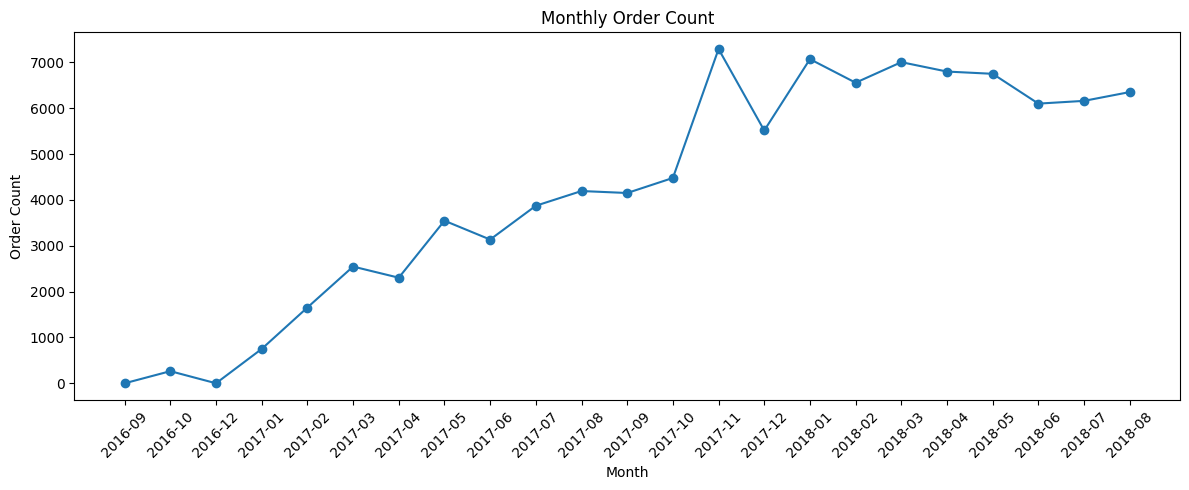

In [4]:
# 每月訂單數

query = """
SELECT
    DATE_FORMAT(order_purchase_timestamp, '%%Y-%%m') AS order_month,
    COUNT(*) AS order_count
FROM orders
WHERE order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

monthly_orders = pd.read_sql(query, engine)
print(monthly_orders.head())

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["order_month"], monthly_orders["order_count"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Order Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_monthly_order_count.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：每月訂單數可以用來判斷平台交易量是否穩定成長，以及是否存在明顯的季節性波動。
- 可能原因：若某些月份訂單數明顯上升，可能與促銷活動、節慶檔期、平台成長或行銷投入有關。
- 商業意義：訂單量上升代表平台需求增加，但仍需要與營收、客單價一起比較，才能判斷成長品質。
- 後續可以深入分析：可以進一步計算每月平均客單價 AOV，判斷營收成長是來自訂單數增加，還是單筆訂單金額提高。

  order_month    revenue
0     2016-09     143.46
1     2016-10   46490.66
2     2016-12      19.62
3     2017-01  127482.37
4     2017-02  271239.32


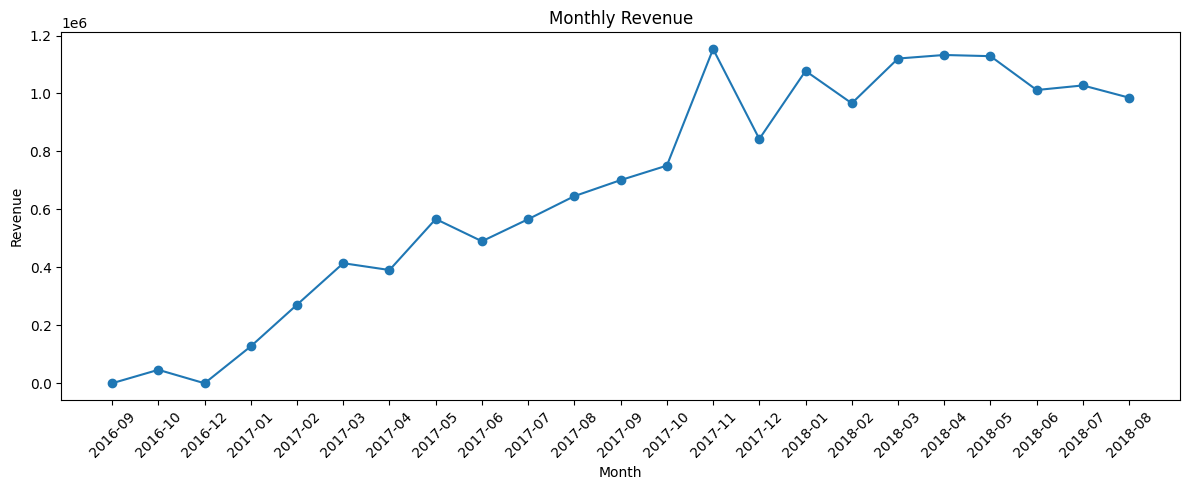

In [5]:
# 每月營收
query = """
SELECT
    DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m') AS order_month,
    SUM(oi.price + oi.freight_value) AS revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

monthly_revenue = pd.read_sql(query, engine)
print(monthly_revenue.head())

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["order_month"], monthly_revenue["revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：每月營收趨勢可以反映平台整體交易金額變化。
- 可能原因：若營收與訂單數同步上升，代表平台交易規模擴大；若訂單數上升但營收沒有同步增加，可能代表客單價下降。
- 商業意義：營收趨勢是判斷電商平台成長狀況的重要指標。
- 後續可以深入分析：可以將每月營收除以每月訂單數，計算每月 AOV，進一步觀察消費金額是否穩定。

                category     revenue
0          health_beauty  1258681.34
1          watches_gifts  1205005.68
2         bed_bath_table  1036988.68
3         sports_leisure   988048.97
4  computers_accessories   911954.32
5        furniture_decor   729762.49
6             cool_stuff   635290.85
7             housewares   632248.66
8                   auto   592720.11
9           garden_tools   485256.46


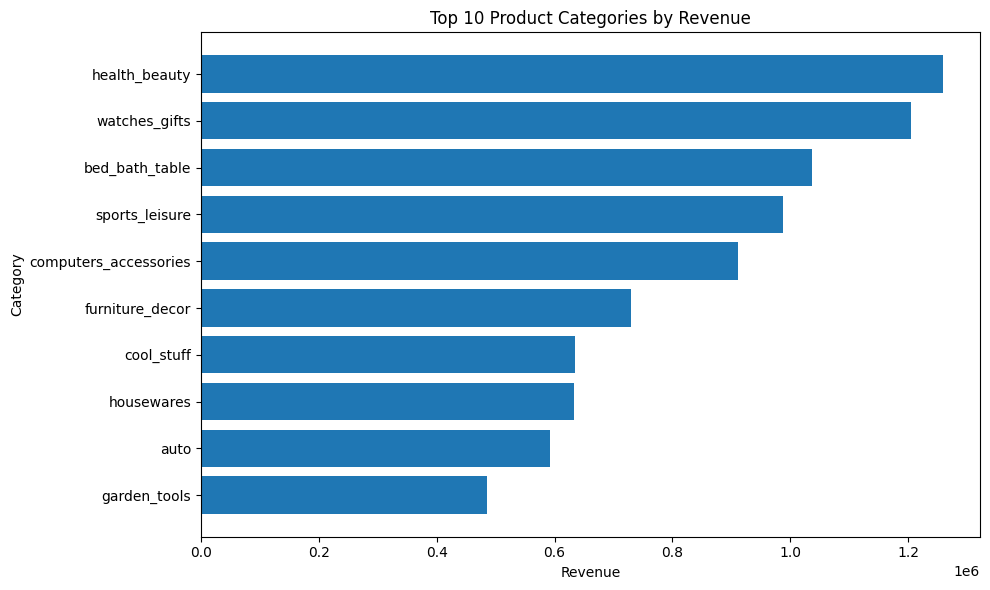

In [6]:
# Top 10 商品品類營收

query = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name) AS category,
    SUM(oi.price) AS revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation t
    ON p.product_category_name = t.product_category_name
GROUP BY category
ORDER BY revenue DESC
LIMIT 10;
"""

top_categories = pd.read_sql(query, engine)
print(top_categories)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["category"], top_categories["revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_top10_categories_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：Top 10 商品品類可以看出平台主要營收來源。
- 可能原因：營收較高的品類可能具有較高需求、較高單價，或較多熱銷商品。
- 商業意義：高營收品類可以作為平台重點經營方向，例如加強庫存、廣告投放與推薦曝光。
- 後續可以深入分析：可以比較各品類的訂單數、平均商品價格與平均運費，判斷營收高是因為銷量高還是單價高。

  payment_type  payment_count
0  credit_card          76795
1       boleto          19784
2      voucher           5775
3   debit_card           1529
4  not_defined              3


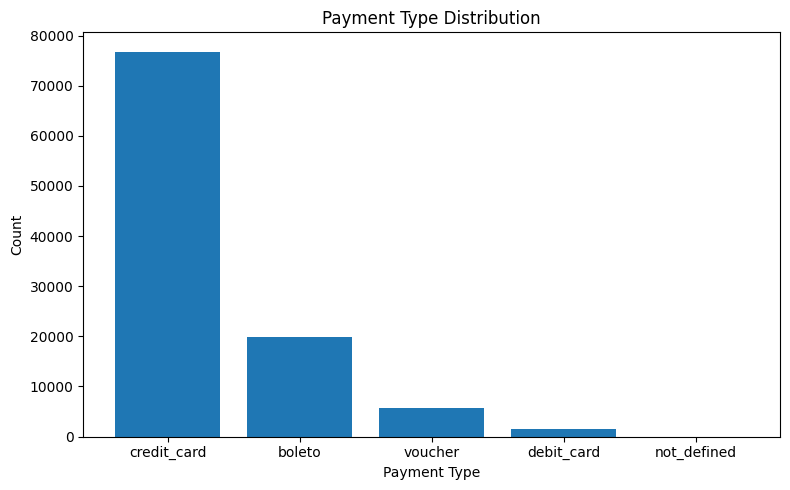

In [7]:
#付款方式分布

query = """
SELECT
    payment_type,
    COUNT(*) AS payment_count
FROM order_payments
GROUP BY payment_type
ORDER BY payment_count DESC;
"""

payment_dist = pd.read_sql(query, engine)
print(payment_dist)

plt.figure(figsize=(8, 5))
plt.bar(payment_dist["payment_type"], payment_dist["payment_count"])
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_payment_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：付款方式分布可以了解顧客主要使用哪些支付工具。
- 可能原因：若信用卡付款占比最高，代表消費者習慣使用信用卡完成線上交易。
- 商業意義：主要付款方式會影響結帳流程設計、分期付款策略與付款失敗風險管理。
- 後續可以深入分析：可以比較不同付款方式的平均訂單金額、評論分數與延遲比例。

   review_score  review_count
0             1         11424
1             2          3151
2             3          8179
3             4         19142
4             5         57328


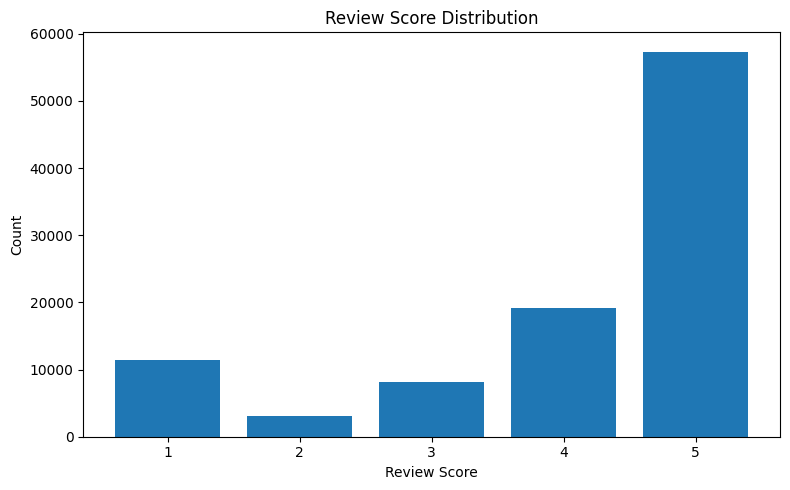

In [8]:
# 評論分數分布
query = """
SELECT
    review_score,
    COUNT(*) AS review_count
FROM order_reviews
GROUP BY review_score
ORDER BY review_score;
"""

review_dist = pd.read_sql(query, engine)
print(review_dist)

plt.figure(figsize=(8, 5))
plt.bar(review_dist["review_score"], review_dist["review_count"])
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_review_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：評論分數分布可以反映顧客整體滿意度。
- 可能原因：若高分評論占多數，代表大部分訂單體驗良好；若低分評論比例不低，可能與物流延遲、商品品質或客服體驗有關。
- 商業意義：評論分數會影響平台信任感，也可以作為後續建立評論好壞預測模型的目標欄位。
- 後續可以深入分析：可以比較延遲訂單與準時訂單的平均評論分數，檢查物流是否明顯影響顧客滿意度。

                           order_id order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   

  order_delivered_customer_date order_estimated_delivery_date  delivery_days  
0           2017-10-10 21:25:13                    2017-10-18              8  
1           2018-08-07 15:27:45                    2018-08-13             13  
2           2018-08-17 18:06:29                    2018-09-04              9  
3           2017-12-02 00:28:42                    2017-12-15             13  
4           2018-02-16 18:17:02                    2018-02-26              2  


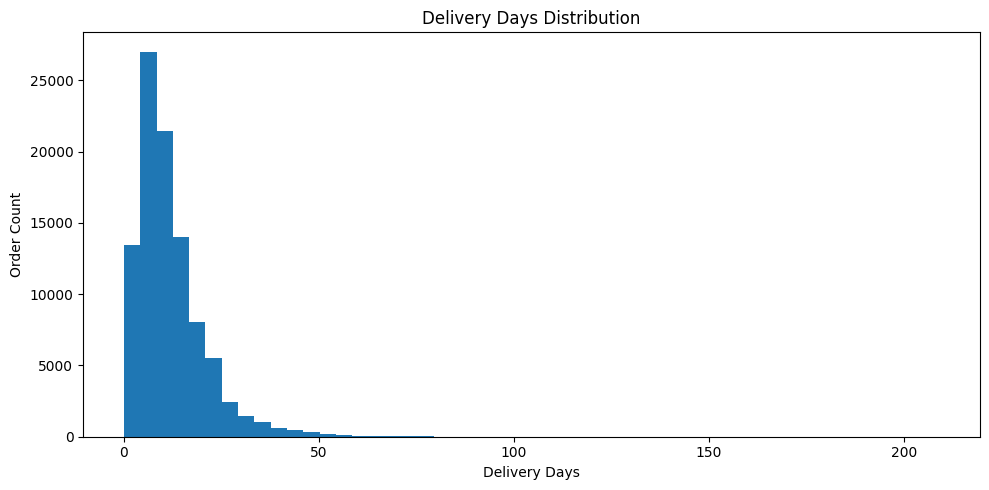

In [9]:
# 物流配送天數
query = """
SELECT
    order_id,
    order_purchase_timestamp,
    order_delivered_customer_date,
    order_estimated_delivery_date
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL;
"""

delivery_df = pd.read_sql(query, engine)

delivery_df["order_purchase_timestamp"] = pd.to_datetime(delivery_df["order_purchase_timestamp"])
delivery_df["order_delivered_customer_date"] = pd.to_datetime(delivery_df["order_delivered_customer_date"])
delivery_df["order_estimated_delivery_date"] = pd.to_datetime(delivery_df["order_estimated_delivery_date"])

delivery_df["delivery_days"] = (
    delivery_df["order_delivered_customer_date"] - delivery_df["order_purchase_timestamp"]
).dt.days

print(delivery_df.head())

plt.figure(figsize=(10, 5))
plt.hist(delivery_df["delivery_days"], bins=50)
plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Order Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_delivery_days_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：配送天數分布可以看出大多數訂單需要多久送達，以及是否存在少數配送時間特別長的訂單。
- 可能原因：配送時間較長可能與顧客地區、賣家地區、物流距離、商品種類或異常訂單有關。
- 商業意義：配送速度是電商顧客體驗的重要因素，配送時間過長可能造成差評或取消訂單。
- 後續可以深入分析：可以依照顧客州別、賣家州別或商品品類比較平均配送天數。

0.08112366538820359
延遲訂單比例：8.11%


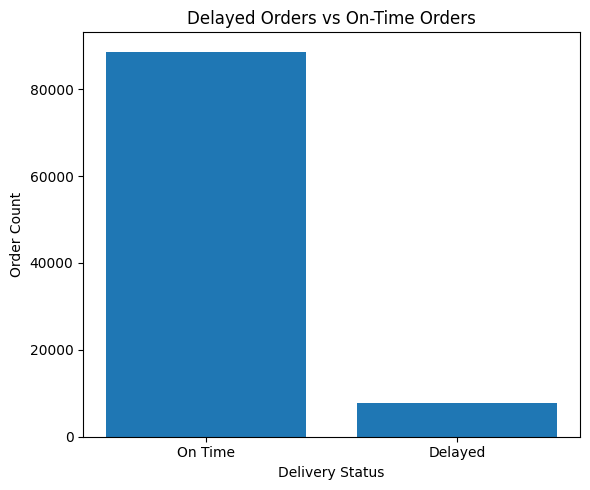

In [10]:
# 延遲訂單比例
delivery_df["is_delayed"] = (
    delivery_df["order_delivered_customer_date"] > delivery_df["order_estimated_delivery_date"]
)

delay_rate = delivery_df["is_delayed"].mean()
print(delay_rate)

print(f"延遲訂單比例：{delay_rate:.2%}")

delay_counts = delivery_df["is_delayed"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(["On Time", "Delayed"], [delay_counts.get(False, 0), delay_counts.get(True, 0)])
plt.title("Delayed Orders vs On-Time Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Order Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_delayed_orders.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：延遲訂單比例可以衡量實際送達日期晚於預估送達日期的情況。
- 可能原因：延遲可能來自物流距離、跨州配送、賣家出貨速度、商品備貨時間或特殊節慶期間物流壅塞。
- 商業意義：延遲訂單會直接影響顧客滿意度，是後續建立「訂單是否延遲預測模型」的重要基礎。
- 後續可以深入分析：可以將 is_delayed 作為 Stage 4 的機器學習 label，預測哪些訂單有較高延遲風險。

  customer_state  order_count
0             SP        40501
1             RJ        12350
2             MG        11354
3             RS         5345
4             PR         4923


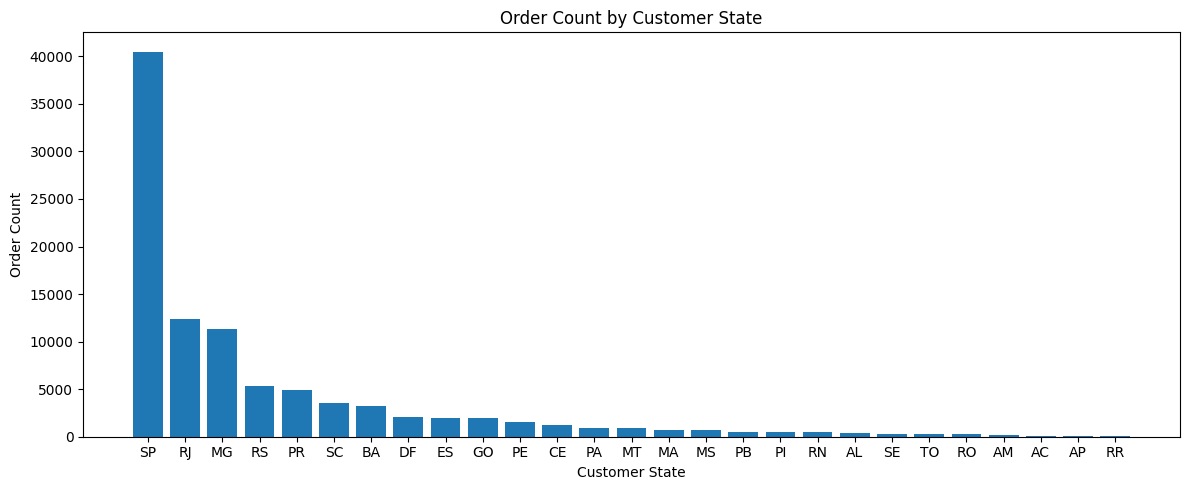

In [11]:
# 各州顧客訂單分布
query = """
SELECT
    c.customer_state,
    COUNT(o.order_id) AS order_count
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY order_count DESC;
"""

state_orders = pd.read_sql(query, engine)
print(state_orders.head())

plt.figure(figsize=(12, 5))
plt.bar(state_orders["customer_state"], state_orders["order_count"])
plt.title("Order Count by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Order Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "olist_customer_state_order_count.png", dpi=300, bbox_inches="tight")
plt.show()

### 商業觀察

- 觀察：各州顧客訂單分布可以看出平台需求主要集中在哪些地區。
- 可能原因：訂單集中地區可能與人口密度、經濟活動、網購普及率或賣家分布有關。
- 商業意義：高訂單州別可以作為物流倉儲、行銷投放與區域營運策略的重要依據。
- 後續可以深入分析：可以比較顧客州別與賣家州別，觀察跨州配送是否影響配送天數與延遲率。